In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

To Directly reproduce the bar graph run the following cells

In [2]:
# Load csv file for plotting the fc1, fc2, fc1fc2, r1, r1fc1fc2
merged_pretrain_and_device_result = pd.read_csv('../../results/postprocessing/subject_specific_transfer_learning_on_device.csv', index_col=0)

In [3]:
# Aggregate pretrained and fine-tuned performance across subjects
# for each unfreezing configuration (layer, learning rate, dW_min)
merged_pretrain_and_device_result_mean = (
    merged_pretrain_and_device_result
    .groupby(['layer unfrozen', 'learning_rate', 'dW_min'])
    .agg(
        # Mean and standard deviation of pretrained accuracy across subjects
        mean_pretrain_acc_accross_subj=('mean_pretrain_val_accuracy', 'mean'),
        std_pretrain_acc=('mean_pretrain_val_accuracy', 'std'),

        # Mean and standard deviation of fine-tuned accuracy across subjects
        mean_finetune_acc_accross_subj=('mean_finetune_val_accuracy', 'mean'),
        std_finetune_acc=('mean_finetune_val_accuracy', 'std'),

        # Standard error of the mean (SEM) for fine-tuned accuracy across subjects
        se_finetune_acc=('mean_finetune_val_accuracy',
                          lambda x: x.std() / np.sqrt(len(x))),
                          
        # Mean and standard error of delta accuracy across subjects
        mean_delta_acc = ('Delta_accuracy', 'mean'),
        se_delta_acc = ('Delta_accuracy', lambda x: x.std() / np.sqrt(len(x)))
    )
    .reset_index()
)

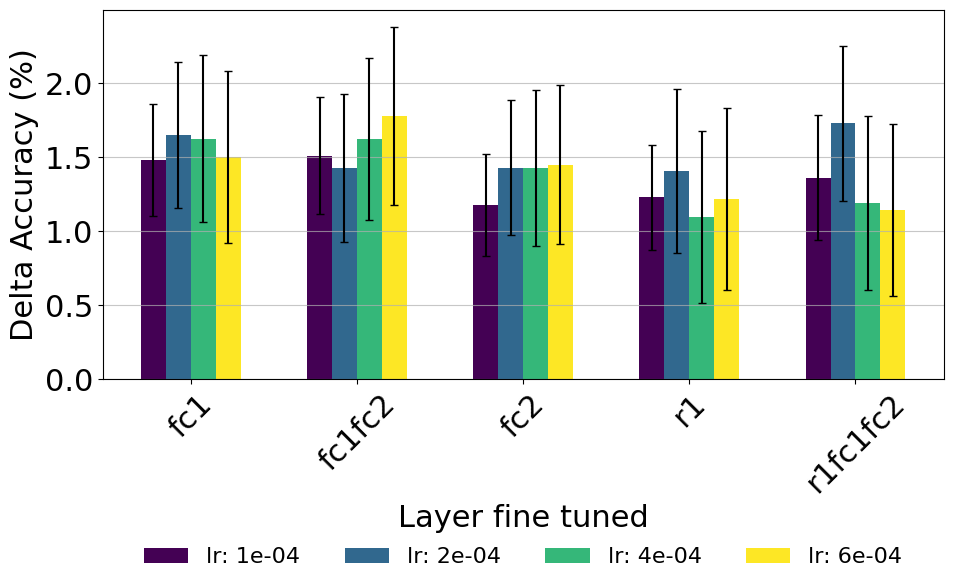

In [4]:
# Set global font size for better readability
plt.rcParams.update({'font.size': 22})

# Create a new figure for the bar plot
plt.figure(figsize=(10, 7))

# Extract unique layers that were fine-tuned and learning rates tested
layers = merged_pretrain_and_device_result_mean['layer unfrozen'].unique()
lrs = merged_pretrain_and_device_result_mean['learning_rate'].unique()

# X positions for each layer group
x = np.arange(len(layers))

# Width of each bar (offset by learning rate)
bar_width = 0.15

# Color map to assign a distinct color to each learning rate
colors = plt.cm.viridis(np.linspace(0, 1, len(lrs)))

# Loop over learning rates to plot grouped bars
for i, lr in enumerate(lrs):
    # Select results corresponding to the current learning rate
    df = merged_pretrain_and_device_result_mean[
        merged_pretrain_and_device_result_mean['learning_rate'] == lr
    ]
    
    # Compute mean delta validation accuracy (fine-tuned − pretrained) per layer
    delta_val_acc = [
        df[df['layer unfrozen'] == layer]['mean_delta_acc'].values[0] * 100
        for layer in layers
    ]
    
    # Extract standard error of delta accuracy per layer
    se_delta_acc = [
        df[df['layer unfrozen'] == layer]['se_delta_acc'].values[0] * 100
        for layer in layers
    ]

    # Plot bar chart with error bars (SEM)
    plt.bar(
        x + i * bar_width,          # horizontal offset for grouping
        delta_val_acc,              # mean delta accuracy (%)
        bar_width,
        label=f'lr: {lr:.0e}',      # learning rate label
        yerr=se_delta_acc,          # error bars (SEM)
        color=colors[i],
        capsize=3                   # cap size for error bars
    )

# Axis labels
plt.xlabel('Layer fine tuned')
plt.ylabel('Delta Accuracy (%)')

# Center x-ticks under grouped bars and rotate labels for clarity
plt.xticks(
    x + bar_width * (len(lrs) - 1) / 2,
    layers,
    rotation=45,
    ha='center'
)

# Add horizontal grid lines to improve readability
plt.grid(axis='y', alpha=0.7)

# Place legend below the plot
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.4),
    ncol=4,
    frameon=False,
    fontsize=16
)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plot
plt.show()

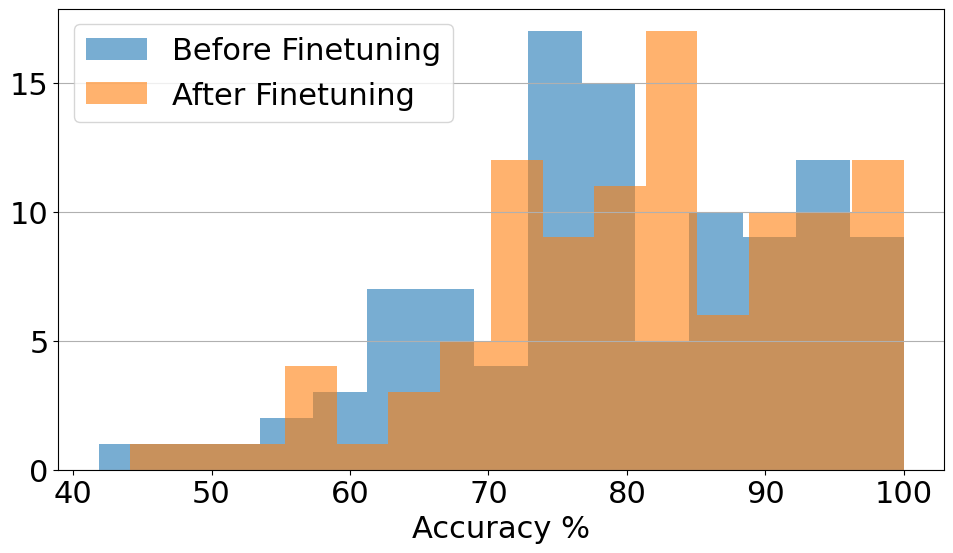

In [5]:
# Extract the data for one selected layer and learning rate (for example fc1fc2, learning rate 6e-4)
merged_pretrain_and_device_result_2 = merged_pretrain_and_device_result[(merged_pretrain_and_device_result['layer unfrozen'] == 'fc1fc2') & (merged_pretrain_and_device_result['learning_rate'] == 0.0006)]

#Histogram to show improvements
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(10,6))

plt.hist(merged_pretrain_and_device_result_2['mean_pretrain_val_accuracy']*100, bins=15, label='Before Finetuning', alpha=0.6)
plt.hist(merged_pretrain_and_device_result_2['mean_finetune_val_accuracy']*100, bins=15, label='After Finetuning', color='tab:orange', alpha=0.6)

plt.grid(axis='y')
plt.legend()
plt.xlabel('Accuracy %')
# plt.title('layer unfrozen fc1fc2')
plt.tight_layout()